# (연구) 2D decomposition with SSA
> 진행형

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [연구]

## Import packages

In [160]:
library(Rssa)

## Testsignal 1 

`-` composite of two components having different frequencies

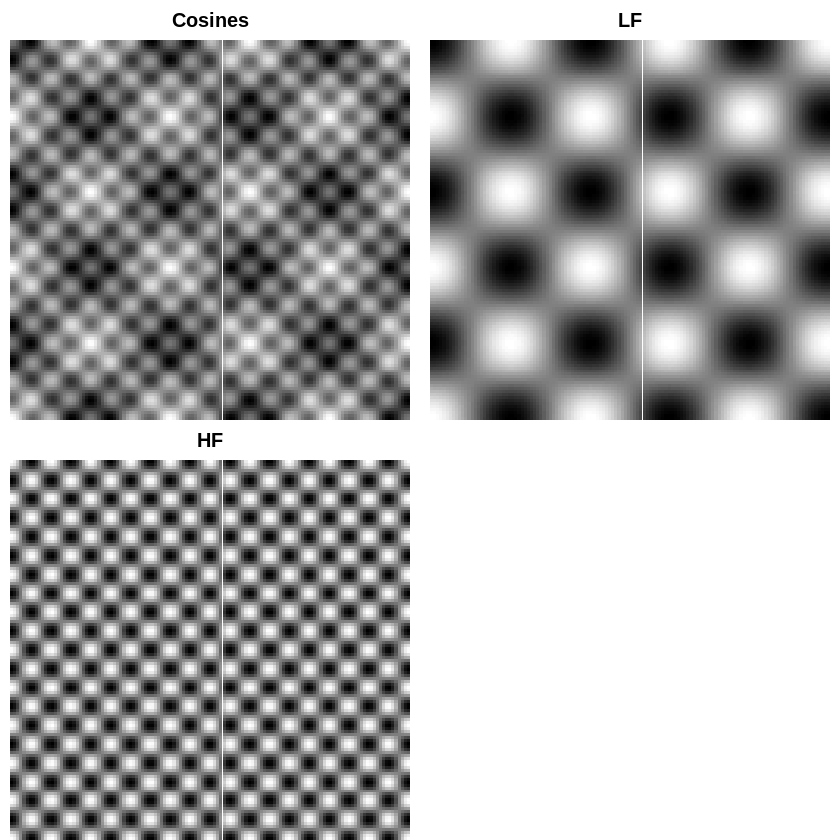

In [171]:
nr <- nc <- 128; x <- y <- seq(0, 1, length=nr)

coscomp1 <- outer(cos(20 * pi * x), cos(20 * pi * y))
coscomp2 <- outer(cos(5* pi * x), cos(5 * pi * y))
cosmeanf <- coscomp1 + coscomp2

par(mfcol=c(2,2), mar=c(0,0.5,2,0.5))
image(cosmeanf, xlab="", ylab="", col=gray(0:100/100), axes=F, main="Cosines")
image(coscomp1, xlab="", ylab="", col=gray(0:100/100), axes=F, main="HF")
image(coscomp2, xlab="", ylab="", col=gray(0:100/100), axes=F, main="LF")

### SSA

`-` Apply SSA to Testsignal 1
   - Reference: Golyandina, N., Korobeynikov, A., Shlemov, A., & Usevich, K. (2013). Multivariate and 2D extensions of singular spectrum analysis with the Rssa package. arXiv preprint arXiv:1309.5050.

`-` Window size is 64*64

`-` The window size can be interpreted as a multiscale parameter.
 - Small window size: Focusing on local changes, advantageous for judging sudden changes in signals; Suitable for analyzing partial normal time series
 - Large window size: Focus on global structure; Suitable for analyzing stationary time series

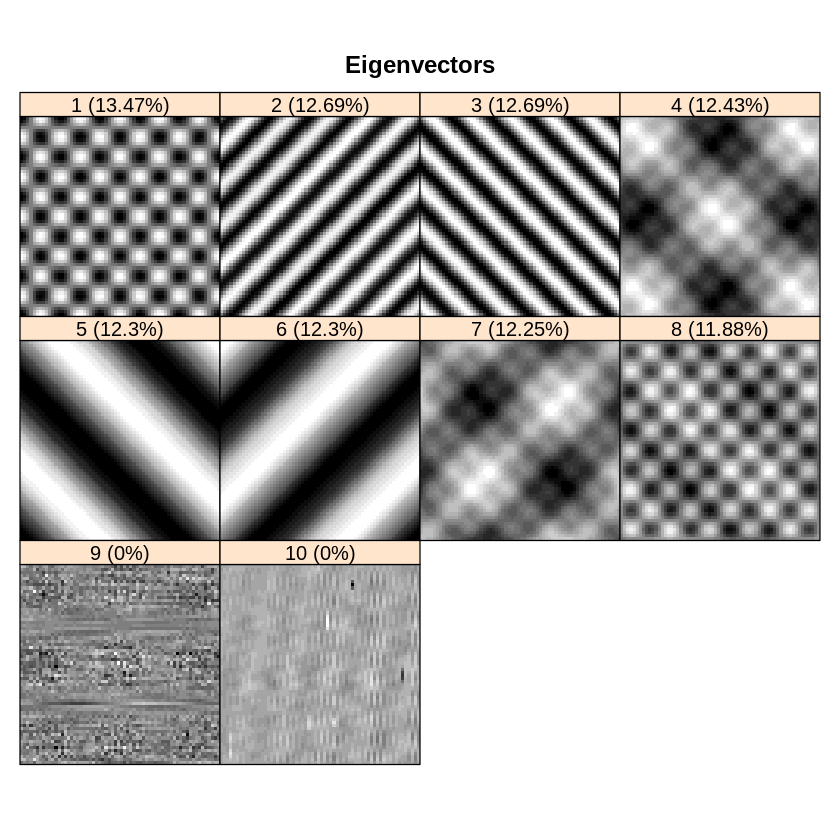

In [184]:
ssarslt<-ssa(cosmeanf, kind="2d-ssa",L=c(64,64))
plot(ssarslt,type="vectors")

`-` Interpretation of ssa results: Some are considered low-frequency and some are considered high-frequency.
 - low-freq: 4,5,6,7
 - high-freq: 1,2,3,8

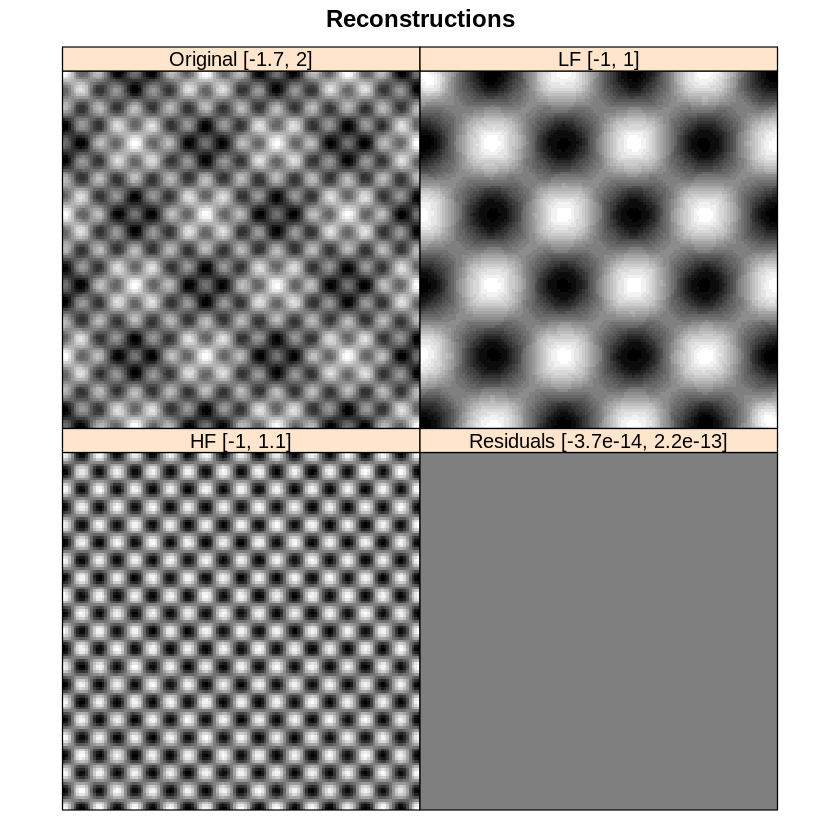

In [185]:
decomprslt<-reconstruct(ssarslt,groups=list(LF=c(4,5,6,7),HF=c(1,2,3,8)))
plot(decomprslt)

`-` What if I select a window that is too small?

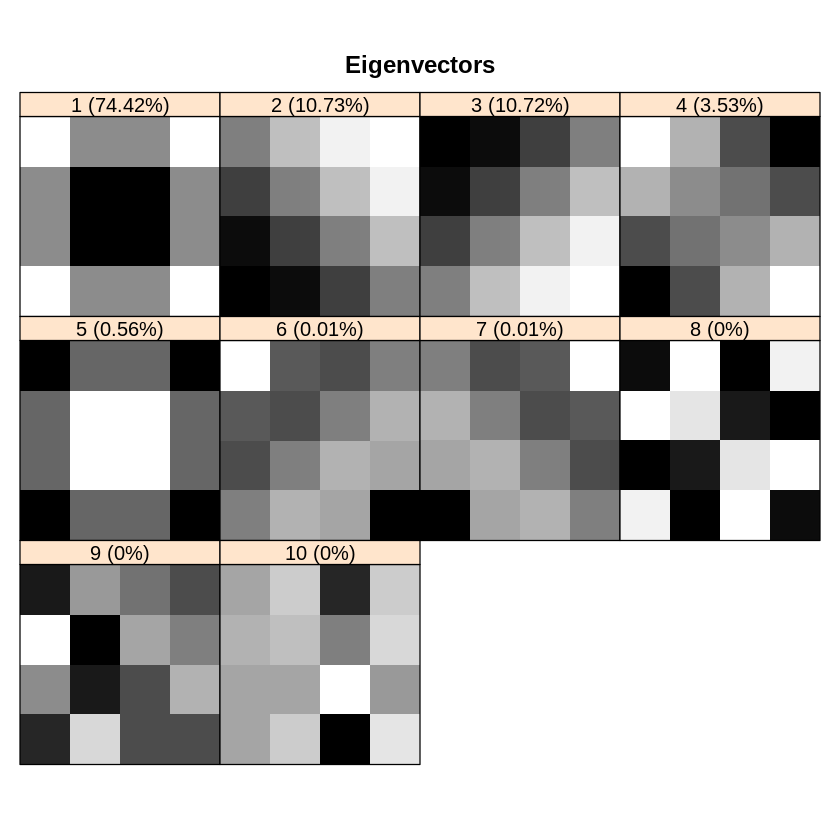

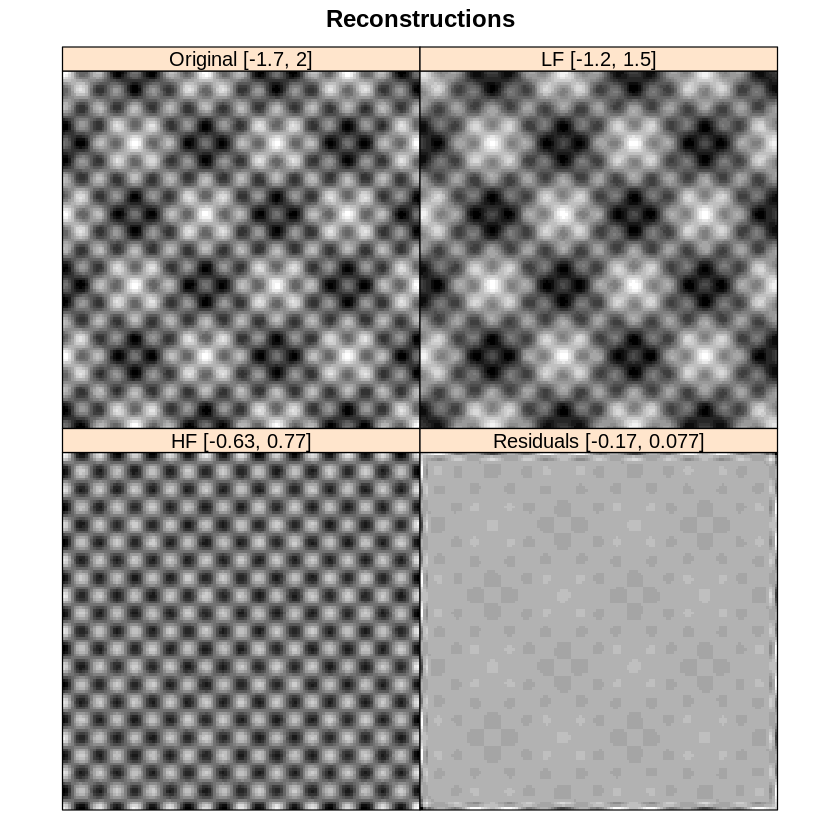

In [188]:
ssarslt<-ssa(cosmeanf, kind="2d-ssa",L=c(4,4))
plot(ssarslt,type="vectors")
decomprslt<-reconstruct(ssarslt,groups=list(LF=c(1,2,3),HF=c(4)))
plot(decomprslt)

`-` It is difficult to separate the global structure (low-freq)

> Note: small window size -> It can't separate global structure (=low freq) properly -> LF contains some HF components.

### 2D PCA

`-` Reference of 2D PCA is as follows
 - Yang, J., Zhang, D., Frangi, A. F., & Yang, J. Y. (2004). Two-dimensional PCA: a new approach to appearance-based face representation and recognition. IEEE transactions on pattern analysis and machine intelligence, 26(1), 131-137.
 - ($\ast$) 2D-PCA는 구현된 코드를 찾기 어려워 일단은 임시로 제가 위 논문의 내용을 직접 구현하여 시뮬레이션 하였습니다. 

In [211]:
A=cosmeanf
G=t(A-mean(A))%*%(A-mean(A)) 
svd_<-svd(G)

`-` Plot the first 10 eigenvalues

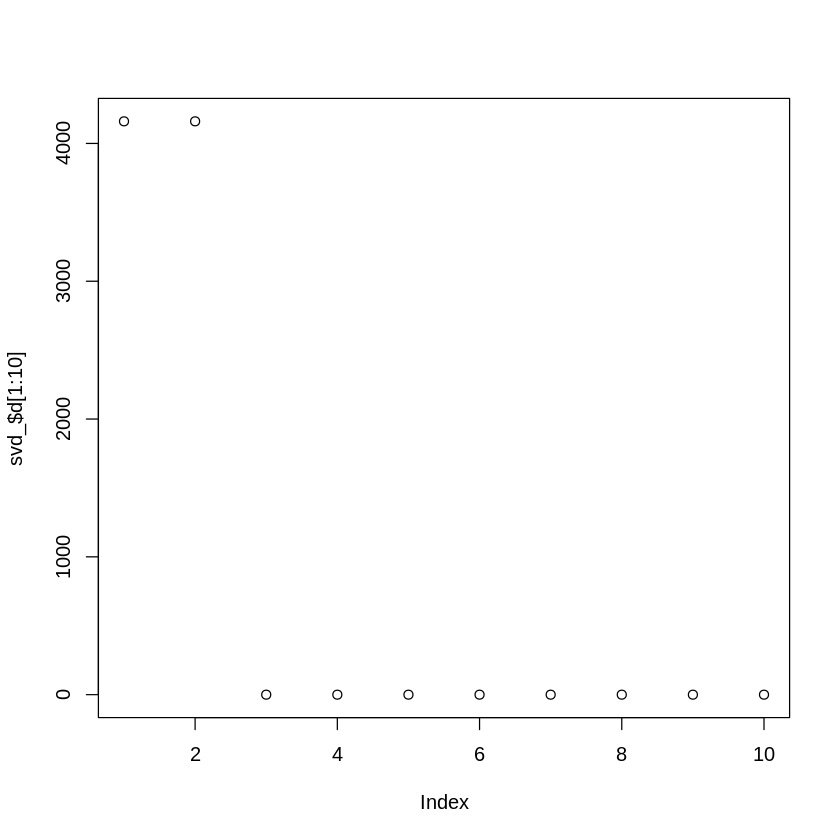

In [213]:
plot(svd_$d[1:10])

`-` There are no significant components after the first two.

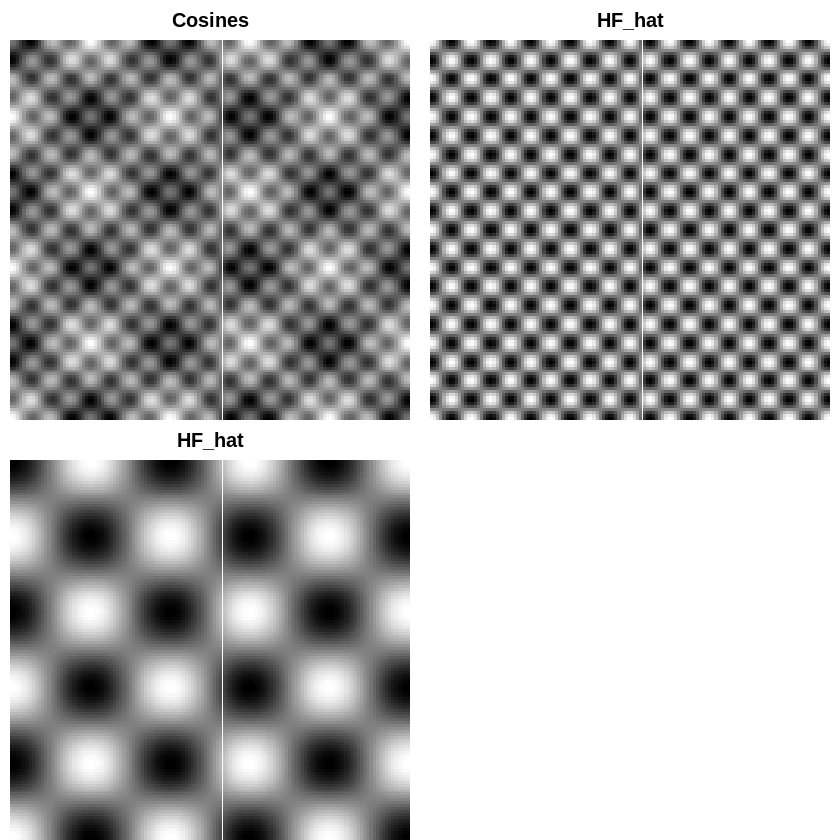

In [195]:
par(mfcol=c(2,2), mar=c(0,0.5,2,0.5))
image(cosmeanf, xlab="", ylab="", col=gray(0:100/100), axes=F, main="Cosines")
#image(coscomp1, xlab="", ylab="", col=gray(0:100/100), axes=F, main="HF_hat")
image(svd_$d[1]*outer(svd_$u[,1], svd_$u[,1] ),xlab="",ylab="", col=gray(0:100/100), axes=F, main="HF_hat")
image(svd_$d[2]*outer(svd_$u[,2], svd_$u[,2] ),xlab="",ylab="", col=gray(0:100/100), axes=F, main="HF_hat")

## Testsignal 2

`-` piecewise stationary signal

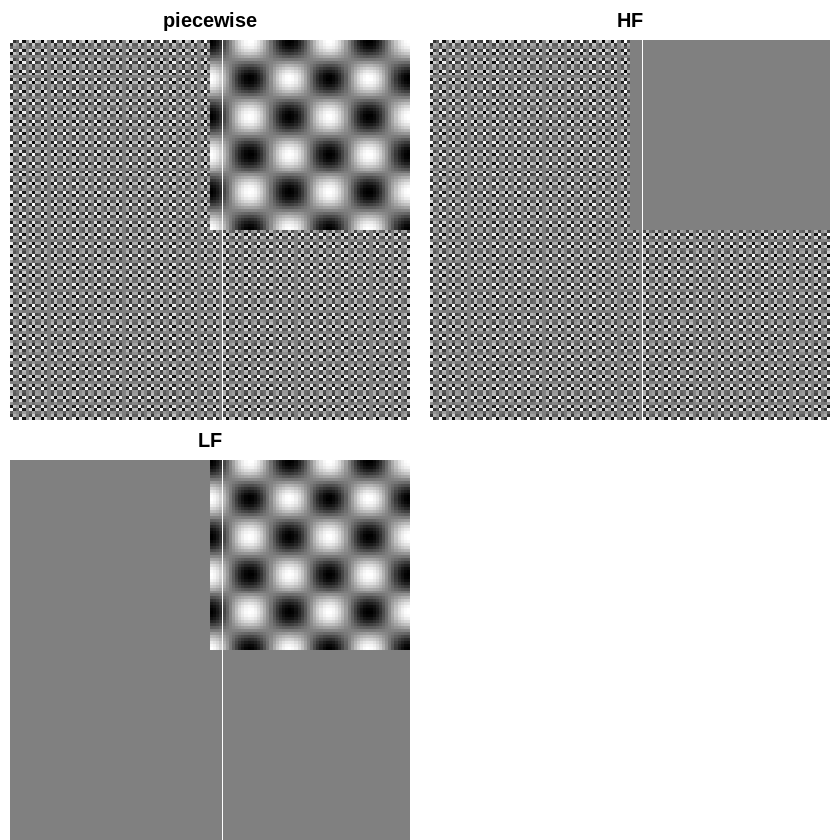

In [199]:
nr <- nc <- 128; x <- y <- seq(0, 1, length=nr)
pcomp1 <- outer(cos(90*pi*x), cos(90*pi*y)); pcomp1[x > 0.5, y > 0.5] <- 0
pcomp2 <- matrix(0, nrow=nr, ncol=nc); pcomp2[x > 0.5, y > 0.5] <- outer(cos(10*pi*x), cos(10*pi*y))[x > 0.5, y > 0.5]
pmeanf <- pcomp1 + pcomp2
par(mfrow=c(2,2), mar=c(0,0.5,2,0.5))
image(pmeanf, xlab="", ylab="", col=gray(0:100/100), axes=F, main="piecewise")
image(pcomp1, xlab="", ylab="", col=gray(0:100/100), axes=F, main="HF")
image(pcomp2, xlab="", ylab="", col=gray(0:100/100), axes=F, main="LF")

### SSA

#### window size = (64,64)

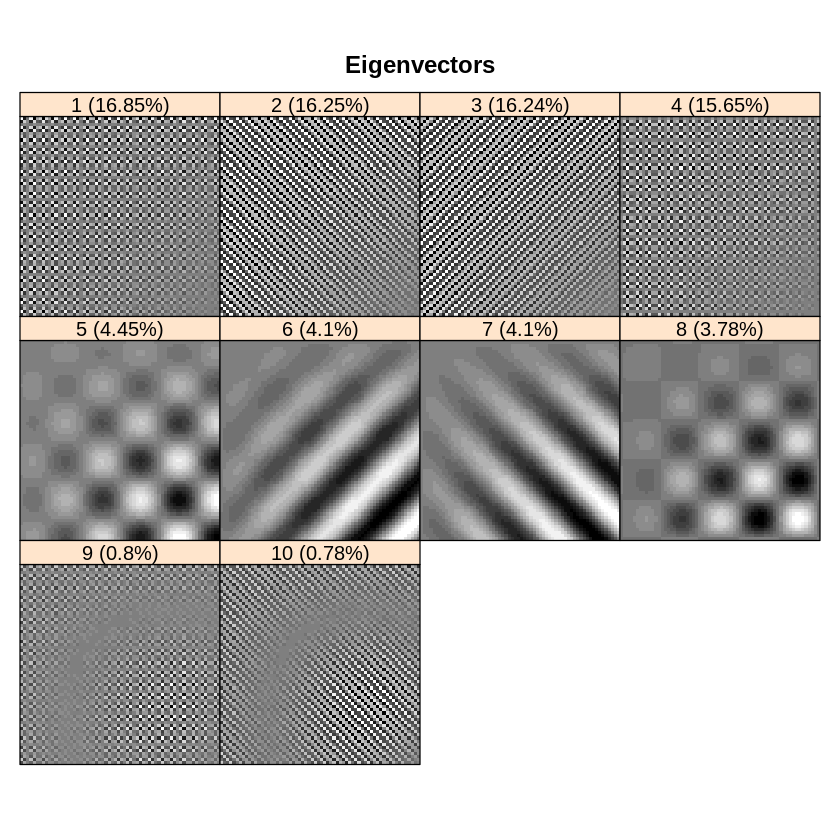

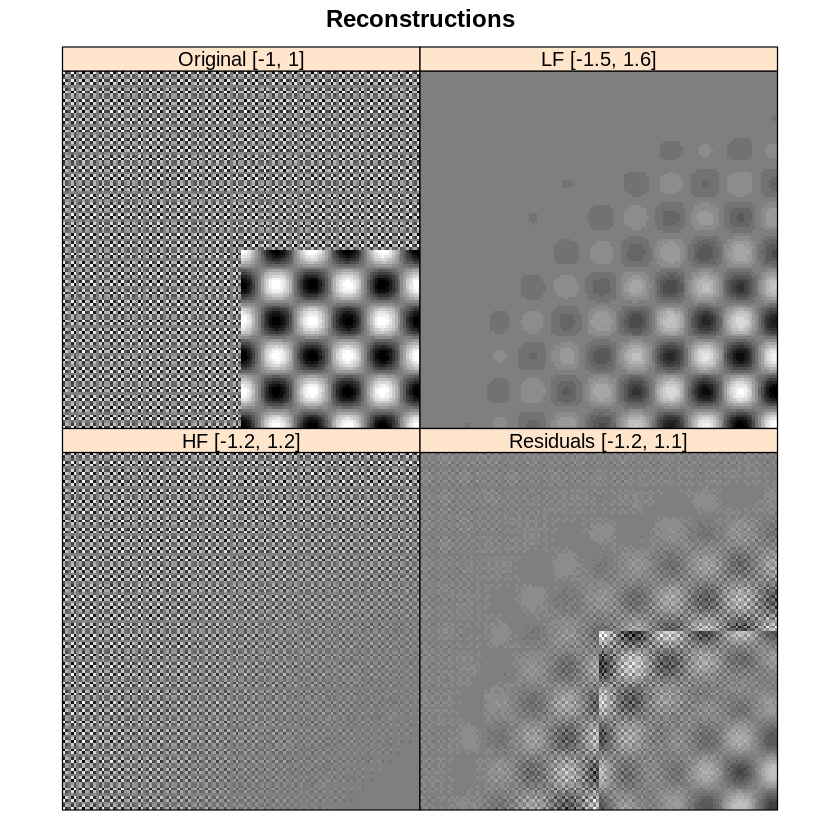

In [200]:
ssarslt<-ssa(pmeanf, kind="2d-ssa",L=c(64,64))
plot(ssarslt,type="vectors")
decomprslt<-reconstruct(ssarslt,groups=list(LF=c(5,6,7,8),HF=c(1,2,3,4)))
plot(decomprslt)

>Note: Large window -> More focus on the global structure -> The point where the frequency fluctuates is smoothed (=distorted) too much 

#### window size = (8,8)

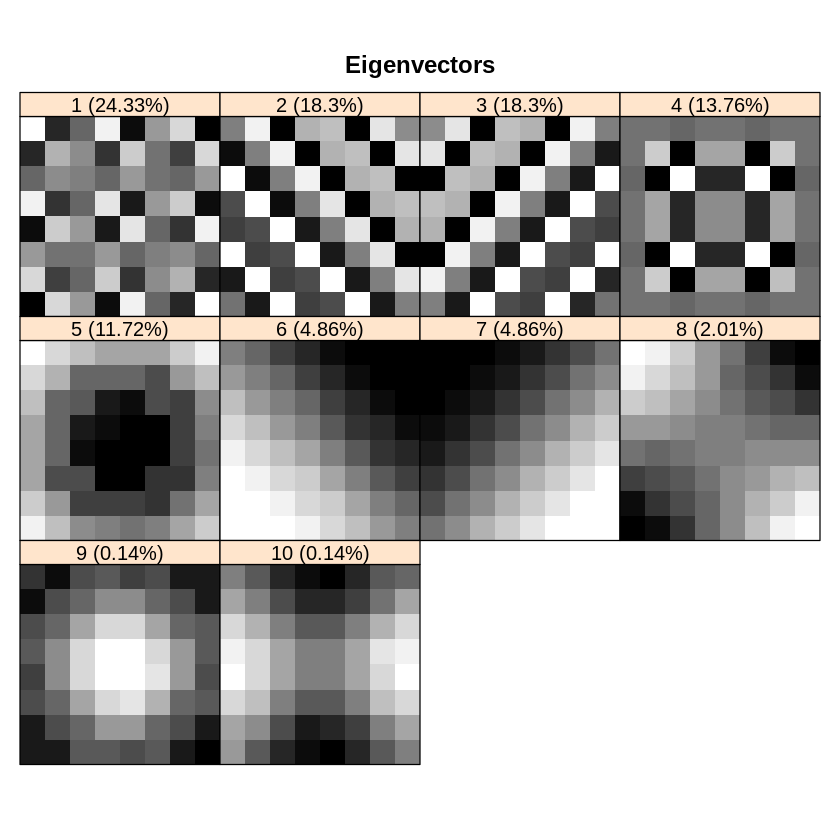

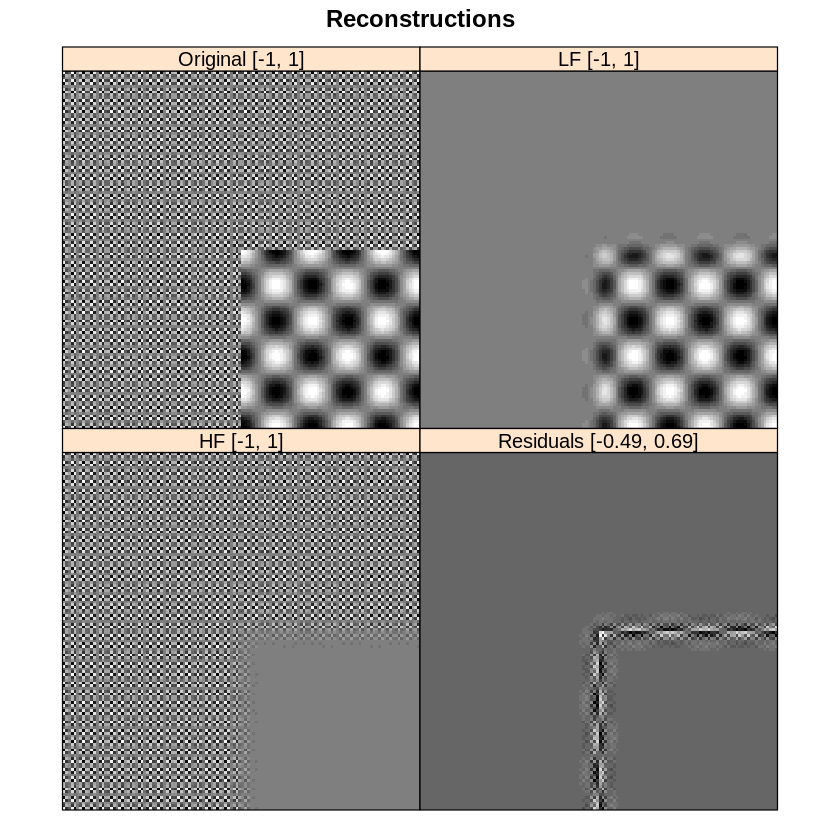

In [116]:
ssarslt<-ssa(pmeanf, kind="2d-ssa",L=c(8,8))
plot(ssarslt,type="vectors")
decomprslt<-reconstruct(ssarslt,groups=list(LF=c(5,6,7,8),HF=c(1,2,3,4)))
plot(decomprslt)

`-` We set the window size to 8*8, so it produced an appropriate result.

`-` It is important to choose the appropriate window size.
 - The window size must be large enough to properly decompose the global structure (=low freq).
 - At the same time, the window should be small enough to sharply detect the area where frequency change occurs.

### 2D-PCA

In [216]:
A=pmeanf
G=t(A-mean(A))%*%(A-mean(A)) 
svd_<-svd(G)

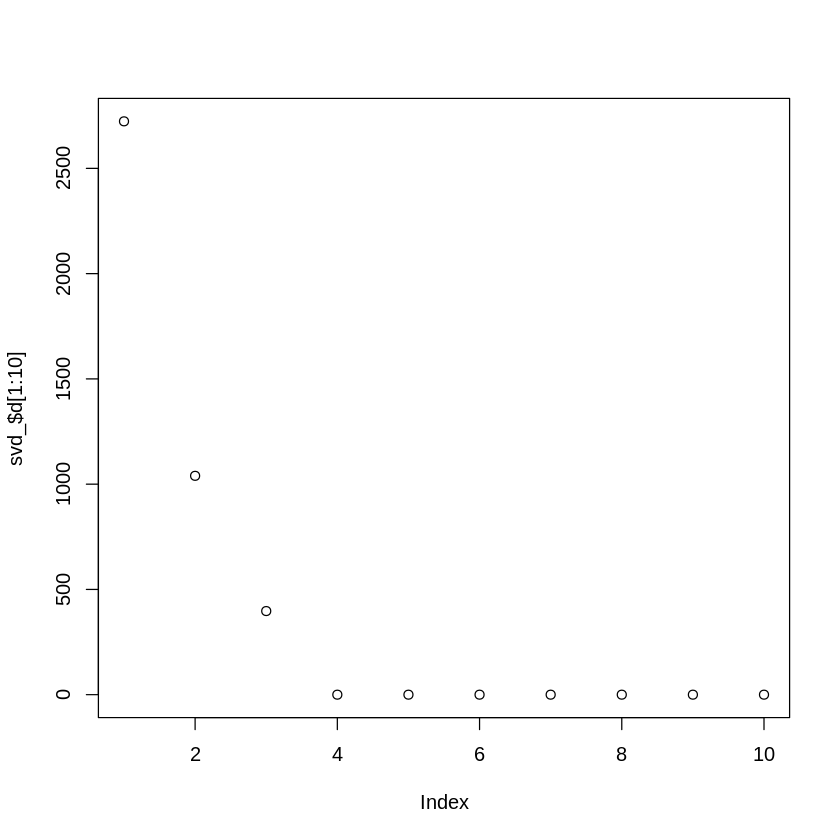

In [217]:
plot(svd_$d[1:10])

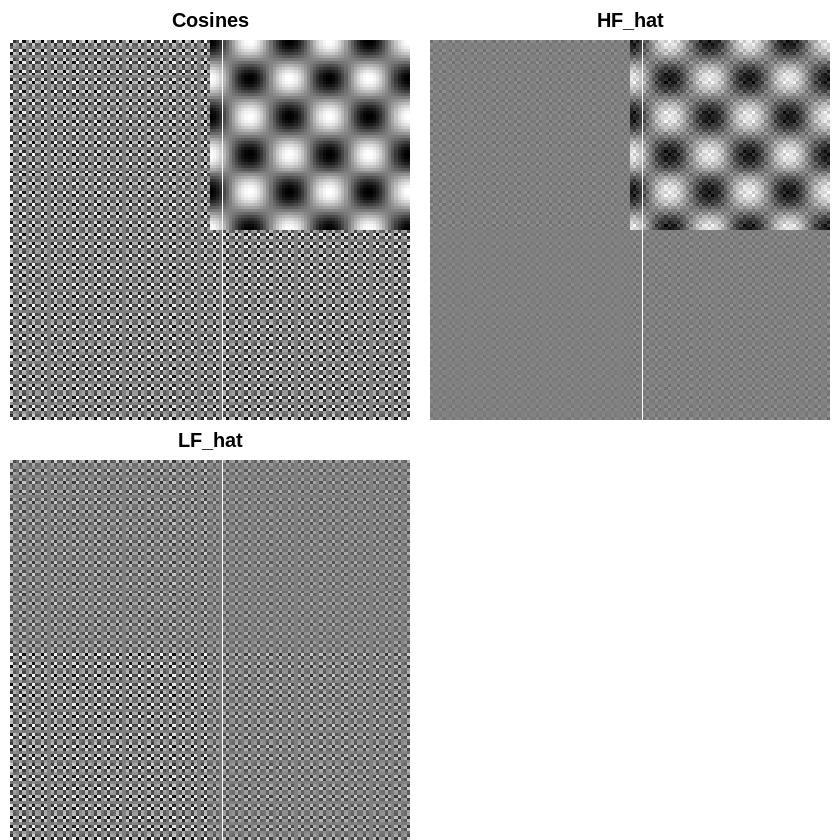

In [221]:
LFhat<- svd_$d[1]*outer(svd_$u[,1], svd_$u[,1]) 
HFhat<- svd_$d[2]*outer(svd_$u[,2], svd_$u[,2]) + svd_$d[3]*outer(svd_$u[,3], svd_$u[,3])
par(mfcol=c(2,2), mar=c(0,0.5,2,0.5))
image(pmeanf, xlab="", ylab="", col=gray(0:100/100), axes=F, main="Cosines")
image(LFhat,xlab="",ylab="", col=gray(0:100/100), axes=F, main="LF_hat")
image(HFhat,xlab="",ylab="", col=gray(0:100/100), axes=F, main="HF_hat")

`-` High-frequency components are mixed in the result of low-frequency decomposition. (see top-right)
 - High-frequency components and low-frequency components are not properly decomposed.
 - 2d pca is not suitable for data with locally stationary.

## TestSignal 3


── Column specification ────────────────────────────────────────────────────────
cols(
  .default = col_double()
)
ℹ Use `spec()` for the full column specifications.




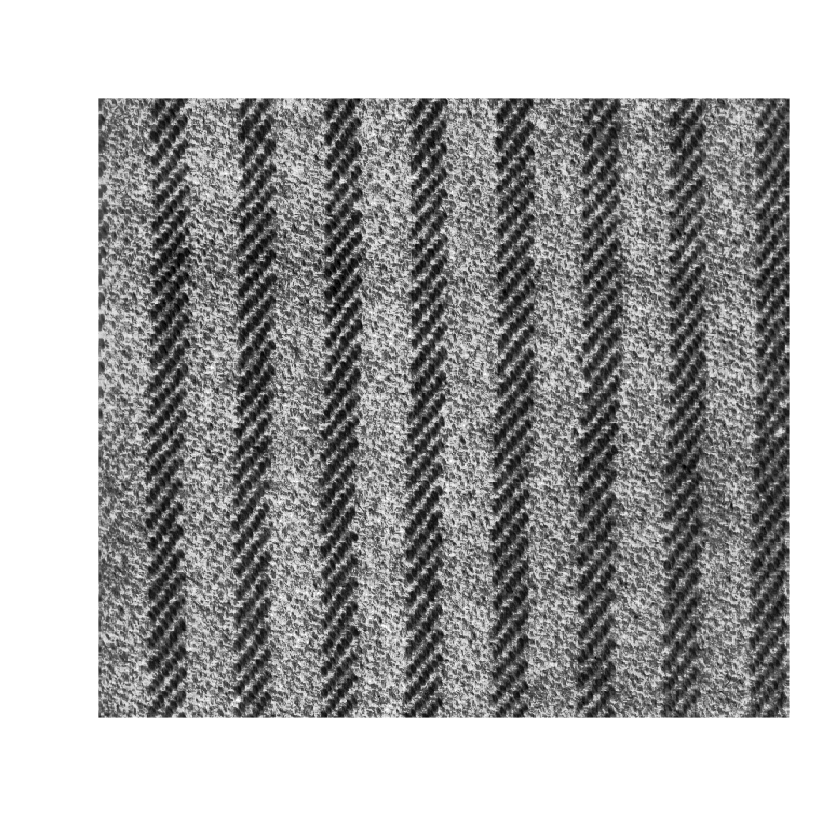

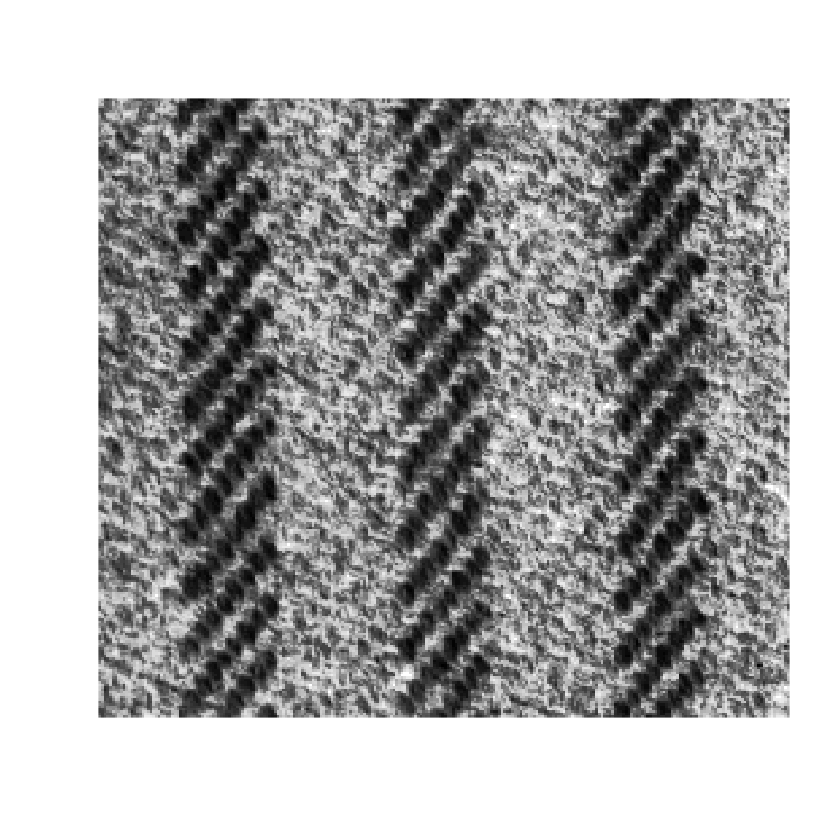

In [263]:
###### Test Image : D11
library(tidyverse)
d11 <- as.matrix(read_csv("https://raw.githubusercontent.com/miruetoto/data/main/d11.csv",col_names=FALSE))
image(d11, xlab="", ylab="", col=gray(0:100/100), axes=F, main="")
d11 <- d11[(1+15):(256+15), 1:256]
image(d11, xlab="", ylab="", col=gray(0:100/100), axes=F, main="")

### SSA

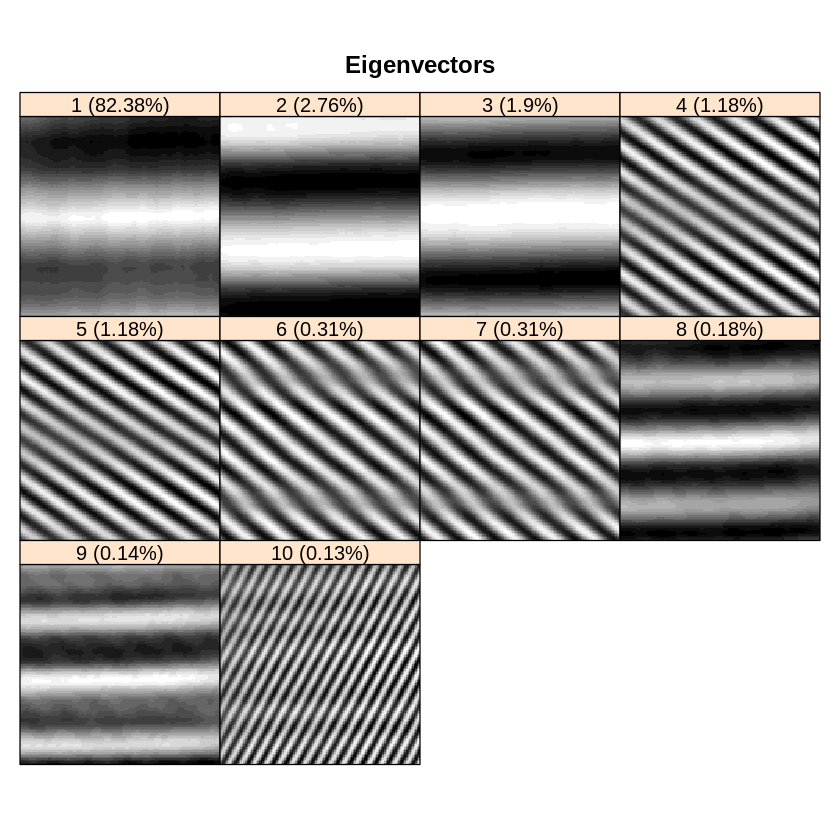

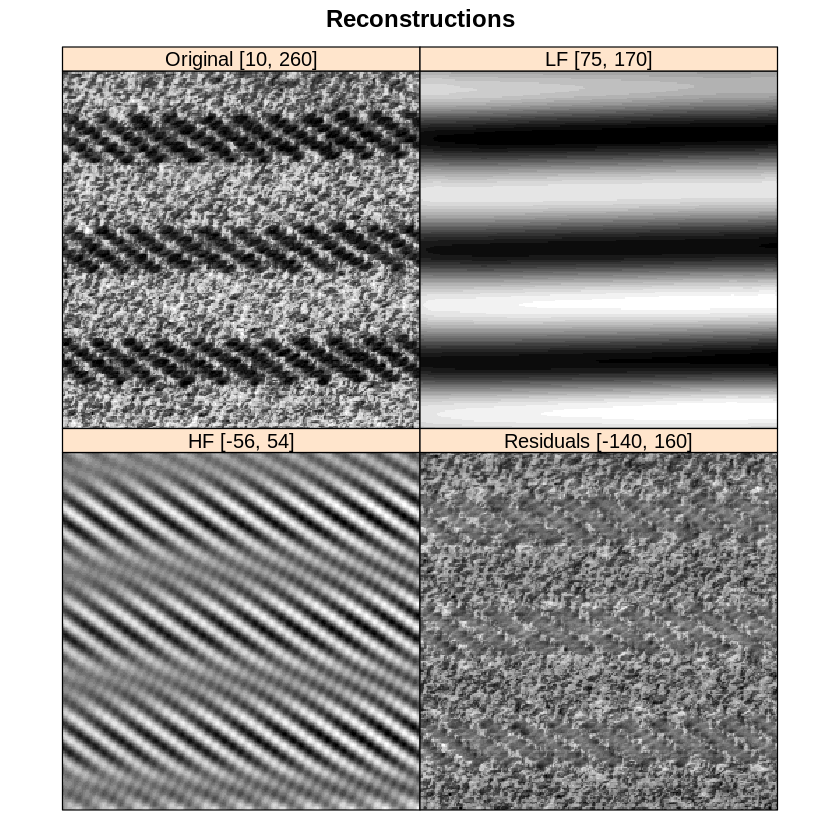

In [278]:
ssarslt<-ssa(d11, kind="2d-ssa",L=c(128,128))
plot(ssarslt,type="vectors")
decomprslt<-reconstruct(ssarslt,groups=list(LF=c(1,2,3),HF=c(4,5,6,7,9,10)))
plot(decomprslt)

### 2D-PCA

In [283]:
A=d11
G=t(A-mean(A))%*%(A-mean(A)) 
svd_<-svd(G)

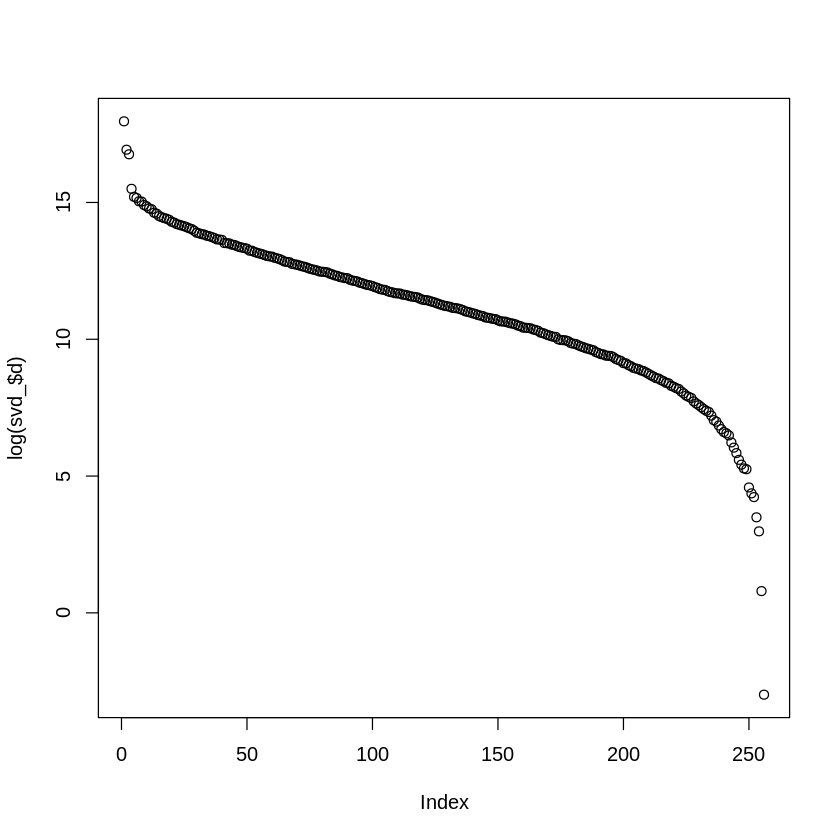

In [288]:
plot(log(svd_$d))

In [ ]:
`-` 

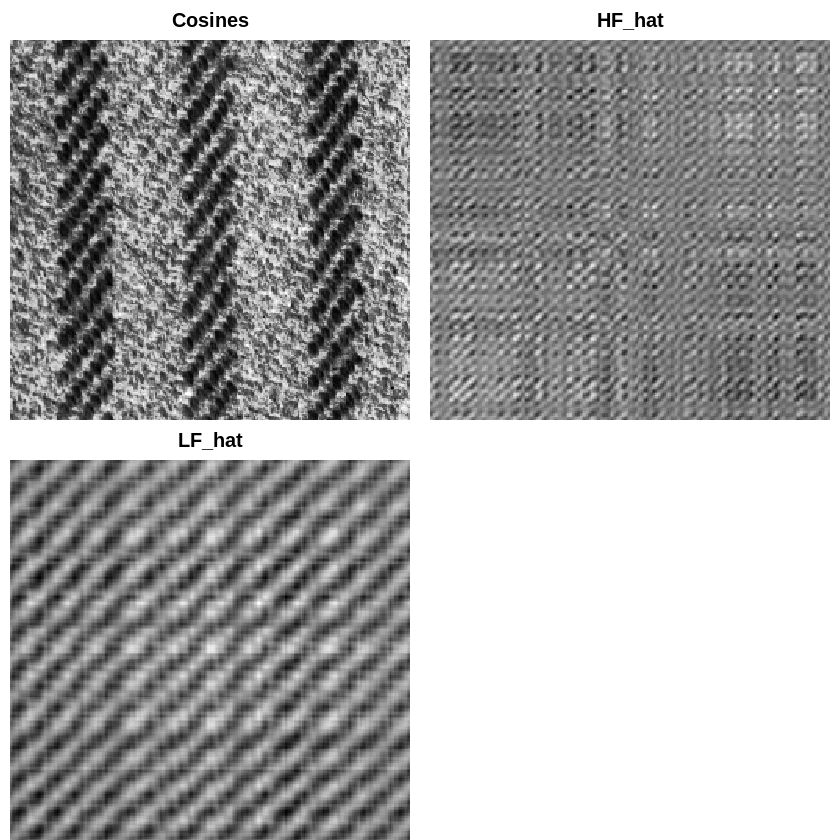

In [289]:
LFhat<- svd_$d[1]*outer(svd_$u[,1], svd_$u[,1]) +svd_$d[2]*outer(svd_$u[,2], svd_$u[,2]) + svd_$d[3]*outer(svd_$u[,3], svd_$u[,3])
HFhat<- svd_$d[4]*outer(svd_$u[,4], svd_$u[,4]) +svd_$d[5]*outer(svd_$u[,5], svd_$u[,5]) + svd_$d[6]*outer(svd_$u[,6], svd_$u[,6])
par(mfcol=c(2,2), mar=c(0,0.5,2,0.5))
image(d11, xlab="", ylab="", col=gray(0:100/100), axes=F, main="Cosines")
image(LFhat,xlab="",ylab="", col=gray(0:100/100), axes=F, main="LF_hat")
image(HFhat,xlab="",ylab="", col=gray(0:100/100), axes=F, main="HF_hat")